# 01. EDA — Adult Census Income

`src/clean.py`, `src/viz.py`의 함수를 재사용해서 데이터 로딩, 기초 EDA, 시각화를 진행한다.

In [1]:
import sys
sys.path.insert(0, '..')  # 프로젝트 루트를 경로에 추가해야 src를 import할 수 있음

from src.clean import load_pandas, load_polars, compare_loaders, basic_eda, load_and_clean
from src.viz import plot_correlation_heatmap, plot_income_by_hours

## 1. 로딩 비교 (pandas vs polars)

In [2]:
pandas_df = load_pandas()
polars_df = load_polars()
compare_loaders(pandas_df, polars_df)

[Pandas] shape: (32561, 15)
[Polars] shape: (32561, 15)

컬럼              pandas dtype  polars dtype  
--------------------------------------------
age             int64         Int64         
workclass       str           String        
fnlwgt          int64         Int64         
education       str           String        
education-num   int64         Int64         
marital-status  str           String        
occupation      str           String        
relationship    str           String        
race            str           String        
sex             str           String        
capital-gain    int64         Int64         
capital-loss    int64         Int64         
hours-per-week  int64         Int64         
native-country  str           String        
income          str           String        


## 2. 기초 EDA (info, describe, value_counts)

In [3]:
basic_eda(pandas_df)

=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB

=== df.describe() (수치형) ===
                age        fnlwgt  education-num  capital-gain  capital-loss  

## 3. 결측치/중복 처리 후 데이터

In [4]:
cleaned_df = load_and_clean()
cleaned_df.head()

중복 제거 전: 32,561행 -> 제거 후: 32,537행 (제거됨: 24행)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 4. 시각화

- Seaborn: 수치형 변수 상관관계 히트맵
- Plotly: income 그룹별 주당 근무시간 분포 (인터랙티브)

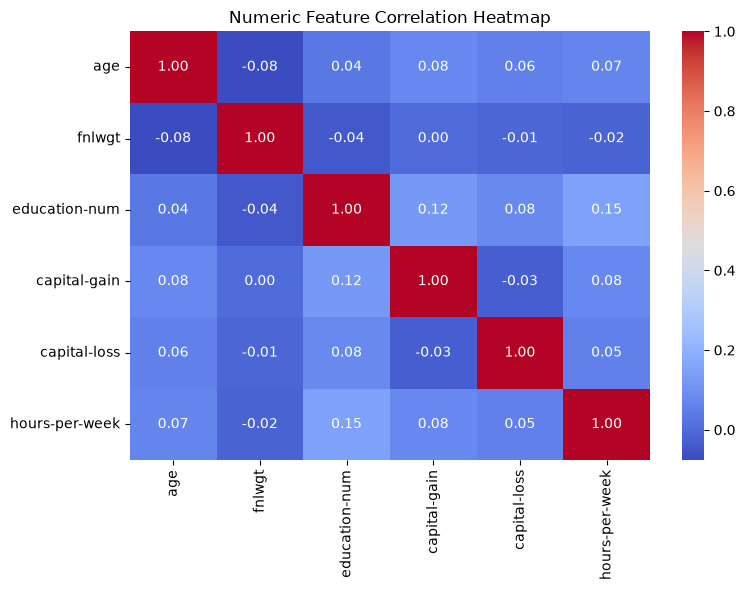

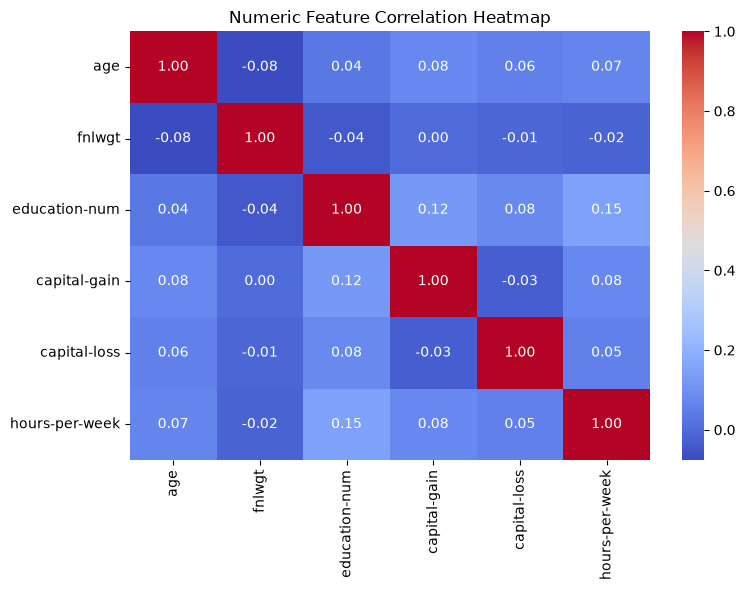

In [5]:
fig = plot_correlation_heatmap(cleaned_df)
fig

In [6]:
fig = plot_income_by_hours(cleaned_df)
fig.show()